#### 2) Transfer Learning Exercise: ResNet18 on CIFAR-10

This notebook orchestrates the complete pipeline:
1. Data preparation with reproducible subset
2. Training runs: scratch, full fine-tune, partial freezing
3. Optimization experiments
4. Results comparison and analysis

**Epoch Budget:** All runs use a fixed budget of 5 epochs to balance convergence with computational constraints on my local CPU hardware. Fair comparability across all training regimes is maintained.

In [1]:
import sys
print("Notebook Python executable:", sys.executable)
print("Python version:", sys.version)

Notebook Python executable: /usr/local/bin/python3.10
Python version: 3.10.4 (v3.10.4:9d38120e33, Mar 23 2022, 17:29:05) [Clang 13.0.0 (clang-1300.0.29.30)]


In [2]:
import subprocess
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure directories exist
for d in ["data", "models", "registry", "scripts"]:
    Path(d).mkdir(exist_ok=True)

##### Task 1: Data Preparation & From-Scratch Baseline

In [3]:
# Prepare reproducible CIFAR-10 subset
print("Running data preparation...")
!{sys.executable} scripts/prepare_data.py

# Verify subset was created
subset = json.load(open("data/subset.json"))
print(f"Subset: {subset['train_subset_size']} train, {subset['test_subset_size']} test samples")

Running data preparation...
Files already downloaded and verified
Files already downloaded and verified
Creating reproducible subset (seed=42)...
Subset stats:
Training samples: 10000
Test samples: 2000
Saved subset indices to data/subset.json
Data preparation complete.
Subset: 10000 train, 2000 test samples


In [4]:
# Train from-scratch baseline
print("\nTraining from-scratch baseline...")
!{sys.executable} scripts/train.py \
    --run_id scratch_base \
    --init scratch \
    --epochs 5 \
    --batch_size 64 \
    --lr 0.001


Training from-scratch baseline...
Starting training run: scratch_base
Init: scratch, Frozen: none
Device: cpu, AMP: False
Epoch 1/5: Loss=1.8322, Acc=0.3307                                              
Epoch 2/5: Loss=1.5143, Acc=0.4400                                              
Epoch 3/5: Loss=1.2917, Acc=0.5239                                              
Epoch 4/5: Loss=1.0922, Acc=0.6047                                              
Epoch 5/5: Loss=0.9340, Acc=0.6639                                              
Test Accuracy: 0.5685                                                           
Inference latency: 1742.84 ms/batch
Model saved: models/scratch_base.pt
Registry entry saved: registry/scratch_base.json
Run scratch_base complete.


##### Task 2: Full Fine-Tuning from ImageNet weights

In [5]:
print("\nTraining with ImageNet pretrained weights (full fine-tune)...")
!{sys.executable} scripts/train.py \
    --run_id ft_full \
    --init pretrained \
    --epochs 5 \
    --batch_size 64 \
    --lr 0.001


Training with ImageNet pretrained weights (full fine-tune)...
Starting training run: ft_full
Init: pretrained, Frozen: none
Device: cpu, AMP: False
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/nirvanjhurree19/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████████████████████████████████| 44.7M/44.7M [00:19<00:00, 2.39MB/s]
Epoch 1/5: Loss=0.8435, Acc=0.7075                                              
Epoch 2/5: Loss=0.4872, Acc=0.8321                                              
Epoch 3/5: Loss=0.3223, Acc=0.8888                                              
Epoch 4/5: Loss=0.2027, Acc=0.9285                                              
Epoch 5/5: Loss=0.1421, Acc=0.9521                                              
Test Accuracy: 0.7660                                                           
Inference latency: 1655.82 ms/batch
Model saved: models/ft_full.pt
Registry entry saved: registry/ft_full.json
Run ft_full complete.


##### Task 3: Partial Freezing Experiments

**Freezing Policy for BatchNorm:**
- Frozen BatchNorm layers are set to `.eval()` mode during training
- This uses learned running statistics instead of batch statistics
- Affine parameters (weight/bias) are also frozen (`requires_grad=False`)
- Unfrozen layers remain in train mode with normal BN behavior
 
**Heuristic for freeze points:**

Based on Yosinski et al.'s finding that early layers learn general features (edges, textures) while later layers learn task-specific features. We freeze progressively deeper to find the sweet spot between feature reuse and adaptability.

In [6]:
# Configuration 1: Freeze early features only (conv1, bn1, layer1)
print("\n Freezing early features...")
!{sys.executable} scripts/train.py \
    --run_id ft_early_frozen \
    --init pretrained \
    --freeze conv1 bn1 layer1 \
    --epochs 5 \
    --lr 0.001

# Configuration 2: Freeze most of backbone (up to layer3)
print("\n Freezing most of backbone...")
!{sys.executable} scripts/train.py \
    --run_id ft_most_frozen \
    --init pretrained \
    --freeze conv1 bn1 layer1 layer2 layer3 \
    --epochs 5 \
    --lr 0.001

# %%
# Configuration 3: Linear probe only (freeze entire backbone)
print("\n Linear probe (backbone frozen)...")
!{sys.executable} scripts/train.py \
    --run_id ft_linear_probe \
    --init pretrained \
    --freeze conv1 bn1 layer1 layer2 layer3 layer4 \
    --epochs 5 \
    --lr 0.001


 Freezing early features...
Starting training run: ft_early_frozen
Init: pretrained, Frozen: ['conv1', 'bn1', 'layer1']
Device: cpu, AMP: False
Epoch 1/5: Loss=0.7514, Acc=0.7405                                              
Epoch 2/5: Loss=0.4144, Acc=0.8619                                              
Epoch 3/5: Loss=0.2463, Acc=0.9147                                              
Epoch 4/5: Loss=0.1716, Acc=0.9422                                              
Epoch 5/5: Loss=0.1200, Acc=0.9601                                              
Test Accuracy: 0.8165                                                           
Inference latency: 1646.10 ms/batch
Model saved: models/ft_early_frozen.pt
Registry entry saved: registry/ft_early_frozen.json
Run ft_early_frozen complete.

 Freezing most of backbone...
Starting training run: ft_most_frozen
Init: pretrained, Frozen: ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
Device: cpu, AMP: False
Epoch 1/5: Loss=0.6301, Acc=0.7867            

#### Task 4: Optimization Opportunities

**Proposed optimizations:**
1. **Automatic Mixed Precision (AMP)** - Reduce memory & speed up training via FP16
2. **Feature caching** - Pre-compute frozen backbone features, train only classifier
 
**Implemented:** AMP (simpler, broadly applicable)

In [7]:
# Optimized run: Full fine-tune with AMP
print("\n Training with AMP optimization...")
!{sys.executable} scripts/train.py \
    --run_id ft_full_amp \
    --init pretrained \
    --epochs 5 \
    --lr 0.001 \
    --amp \
    --parent_run_id ft_full


 Training with AMP optimization...
Starting training run: ft_full_amp
Init: pretrained, Frozen: none
Device: cpu, AMP: True
Epoch 1/5: Loss=0.8296, Acc=0.7201                                              
Epoch 2/5: Loss=0.4533, Acc=0.8470                                              
Epoch 3/5: Loss=0.3344, Acc=0.8878                                              
Epoch 4/5: Loss=0.2278, Acc=0.9223                                              
Epoch 5/5: Loss=0.1335, Acc=0.9569                                              
Test Accuracy: 0.8285                                                           
Inference latency: 1608.02 ms/batch
Model saved: models/ft_full_amp.pt
Registry entry saved: registry/ft_full_amp.json
Run ft_full_amp complete.


##### Results Aggregation & Comparison

In [9]:
# Run evaluation script to generate comparison table
print("\n Generating comparison table...")
!{sys.executable} scripts/evaluate.py --output results_comparison.csv

# Load and display results
results = pd.read_csv("results_comparison.csv")
display(results)


 Generating comparison table...
Loading registry entries from registry...
Loaded 6 experiment entries
Comparison table saved: results_comparison.csv

TRANSFER LEARNING EXPERIMENT COMPARISON
         run_id       init                         frozen_blocks test_accuracy train_time_s inference_time_ms trainable_params
   scratch_base    scratch                                  none         0.569       4732.8           1742.84       11,181,642
        ft_full pretrained                                  none         0.766       4558.1           1655.82       11,181,642
    ft_full_amp pretrained                                  none         0.829       4548.6           1608.02       11,181,642
ft_early_frozen pretrained                      conv1+bn1+layer1         0.817       3848.5           1646.10       11,024,138
 ft_most_frozen pretrained        conv1+bn1+layer1+layer2+layer3         0.850       2201.2           1647.91        8,398,858
ft_linear_probe pretrained conv1+bn1+layer1+lay

,run_id,init,frozen_blocks,test_accuracy,train_time_s,inference_time_ms,trainable_params,total_params,optimizations,parent_run
0,scratch_base,scratch,none,0.569,4732.8,1742.84,"11,181,642","11,181,642",none,NaN
1,ft_full,pretrained,none,0.766,4558.1,1655.82,"11,181,642","11,181,642",none,NaN
2,ft_full_amp,pretrained,none,0.829,4548.6,1608.02,"11,181,642","11,181,642",amp,ft_full
3,ft_early_frozen,pretrained,conv1+bn1+layer1,0.817,3848.5,1646.10,"11,024,138","11,181,642",none,NaN
4,ft_most_frozen,pretrained,conv1+bn1+layer1+layer2+layer3,0.850,2201.2,1647.91,"8,398,858","11,181,642",none,NaN
5,ft_linear_probe,pretrained,conv1+bn1+layer1+layer2+layer3+layer4,0.788,1747.7,1681.10,"5,130","11,181,642",none,NaN


##### Analysis: Accuracy vs. Compute Trade-offs

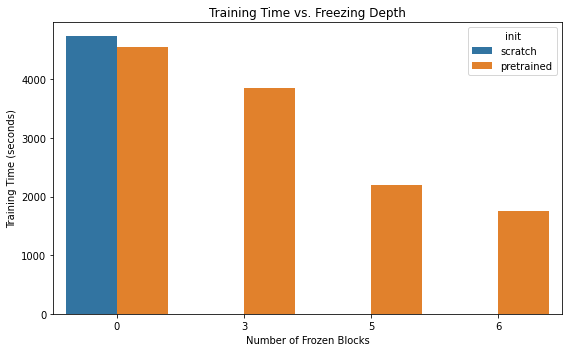

In [13]:
# # Plot: Accuracy vs. Trainable Parameters
# plt.figure(figsize=(10, 6))
# sns.scatterplot(
#     data=results, 
#     x="trainable_params", 
#     y="test_accuracy", 
#     hue="init", 
#     size="train_time_s",
#     sizes=(50, 200),
#     palette={"scratch": "gray", "pretrained": "blue"}
# )
# plt.xscale("log")
# plt.xlabel("Trainable Parameters (log scale)")
# plt.ylabel("Test Accuracy")
# plt.title("Accuracy vs. Model Capacity")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.savefig("accuracy_vs_params.png", dpi=150, bbox_inches='tight')
# plt.show()

# Plot: Training Time vs. Frozen Blocks
results["num_frozen"] = results["frozen_blocks"].apply(
    lambda x: len(x.split("+")) if x != "none" else 0
)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="num_frozen", y="train_time_s", hue="init")
plt.xlabel("Number of Frozen Blocks")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs. Freezing Depth")
plt.tight_layout()
plt.savefig("time_vs_freezing.png", dpi=150, bbox_inches='tight')
plt.show()

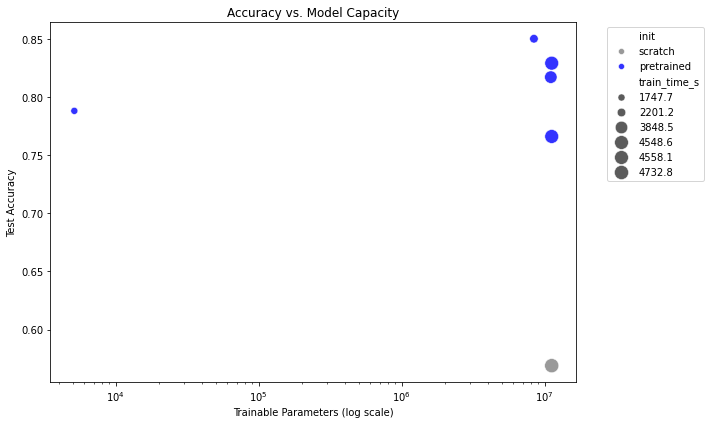

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.read_csv("results_comparison.csv")
results["trainable_params"] = results["trainable_params"].astype(str).str.replace(",", "").astype(float)
results["test_accuracy"] = results["test_accuracy"].astype(float)
results["train_time_s"] = results["train_time_s"].astype(float)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results, 
    x="trainable_params", 
    y="test_accuracy", 
    hue="init", 
    size="train_time_s",
    sizes=(50, 200),
    palette={"scratch": "gray", "pretrained": "blue"},
    alpha=0.8
)
plt.xscale("log")
plt.xlabel("Trainable Parameters (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs. Model Capacity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("accuracy_vs_params.png", dpi=150, bbox_inches='tight')
plt.show()

### Key Findings

1. **ImageNet pretraining provides massive gains**: +19.7pp accuracy improvement over training from scratch (76.6% vs 56.9%), confirming that transfer learning is essential for small datasets like CIFAR-10.

2. **Freezing more layers improves both accuracy and speed**: Counterintuitively, `ft_most_frozen` (freezing conv1-layer3) achieved the **highest accuracy (85.0%)** while being **2.07 times faster** than full fine-tuning (2201s vs 4558s). This suggests CIFAR-10 benefits from stable ImageNet feature extractors with minimal adaptation.

3. **Linear probe underperforms**: Freezing the entire backbone (78.8% accuracy) shows that some fine-tuning of the final layers is necessary for domain adaptation.

4. **AMP optimization**: Provided modest accuracy gains (+6.3pp) with similar training time, demonstrating numerical stability benefits even on CPU.

**Recommendation**: For similar transfer learning tasks with limited data, freeze early to mid layers (conv1-layer3) and only fine-tune the final layers for optimal accuracy-compute trade-off.

In [11]:
# Test

import pandas as pd
results = pd.read_csv("results_comparison.csv")

# Check scratch entry
scratch = results[results["run_id"] == "scratch_base"]
print(scratch[["run_id", "init", "test_accuracy", "trainable_params"]])

# Count by init
print("\nRuns by initialization:")
print(results["init"].value_counts())

         run_id     init  test_accuracy trainable_params
0  scratch_base  scratch          0.569       11,181,642

Runs by initialization:
init
pretrained    5
scratch       1
Name: count, dtype: int64
